# Integrating a Network

Here we show how to create a python network and integrate
it with the [SciPy library](https://scipy.org).

In [1]:
import pynucastro as pyna

We'll start again with the basic CNO network explored earlier.  Again, we'll read in the entire ReacLib library
and pass in the names of the rates in the form of a string `A(x,y)B` to filter out just the rates we are interested in.

In [2]:
rl = pyna.ReacLibLibrary()

In [3]:
rate_names = ["c12(p,g)n13",
              "c13(p,g)n14",
              "n13(,)c13",
              "n13(p,g)o14",
              "n14(p,g)o15",
              "n15(p,a)c12",
              "o14(,)n14",
              "o15(,)n15"]

rates = rl.get_rate_by_name(rate_names)
rates

[C12 + p ⟶ N13 + 𝛾,
 C13 + p ⟶ N14 + 𝛾,
 N13 ⟶ C13 + e⁺ + 𝜈,
 N13 + p ⟶ O14 + 𝛾,
 N14 + p ⟶ O15 + 𝛾,
 N15 + p ⟶ He4 + C12,
 O14 ⟶ N14 + e⁺ + 𝜈,
 O15 ⟶ N15 + e⁺ + 𝜈]

A {py:obj}`PythonNetwork <pynucastro.networks.python_network.PythonNetwork>` is based on a `RateCollection` but has methods to write the RHS of the system of ODEs.

In [4]:
pynet = pyna.PythonNetwork(rates=rates)

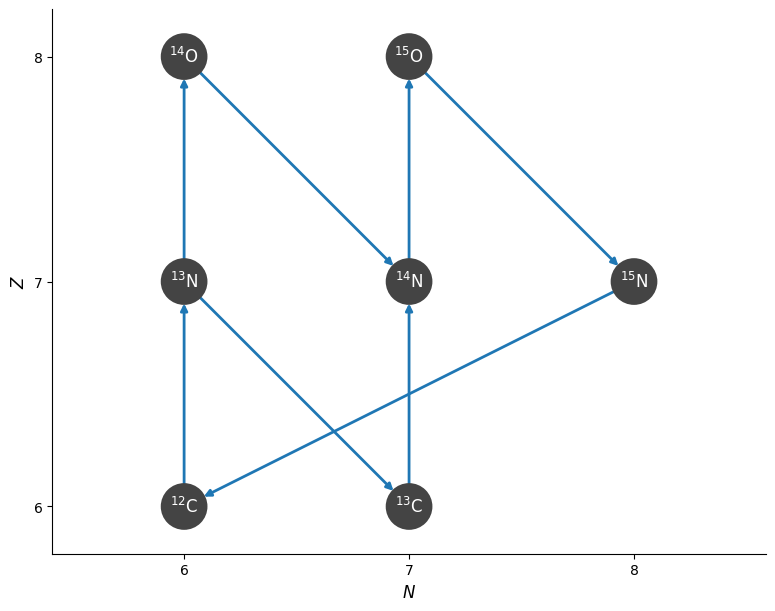

In [5]:
fig = pynet.plot()

For example, this network knows how to write the full term for a reaction that goes into the $dY/dt$ equation of the ODE system.

Here we pick one of the rates that is part of the network an explore it.

In [6]:
r = pynet.rates[1]
print(r)

C13 + p ⟶ N14 + 𝛾


a rate also knows what its contribution is to the $dY/dt$ equation is (through the {py:obj}`ydot_string_py <pynucastro.rates.rate.Rate.ydot_string_py>` method):

In [7]:
print(r.ydot_string_py())

rho*Y[jp]*Y[jc13]*rate_eval.p_C13_to_N14_reaclib


and the python code needed to evaluate this rate (the T-dependent part) is constructed by the `ReacLibRate` class {py:obj}`function_string_py <pynucastro.rates.reaclib_rate.ReacLibRate.function_string_py>` method:

In [8]:
print(r.function_string_py())

@numba.njit()
def p_C13_to_N14_reaclib(rate_eval, tf, log_scor=0.0):
    # C13 + p --> N14
    rate = 0.0

    # nacrn
    ln_set_rate =  18.5155 + -13.72*tf.T913i + -0.450018*tf.T913 \
                         + 3.70823*tf.T9 + -1.70545*tf.T953 + -0.666667*tf.lnT9

    ln_set_rate += log_scor
    set_rate = np.exp(ln_set_rate)
    rate += set_rate

    # nacrr
    ln_set_rate =  13.9637 + -5.78147*tf.T9i + -0.196703*tf.T913 \
                         + 0.142126*tf.T9 + -0.0238912*tf.T953 + -1.5*tf.lnT9

    ln_set_rate += log_scor
    set_rate = np.exp(ln_set_rate)
    rate += set_rate

    # nacrr
    ln_set_rate =  15.1825 + -13.5543*tf.T9i \
                         + -1.5*tf.lnT9

    ln_set_rate += log_scor
    set_rate = np.exp(ln_set_rate)
    rate += set_rate

    rate_eval.p_C13_to_N14_reaclib = rate




```{note}
The temperature-dependent rate evaluation functions take a `Tfactor` object, which precomputes most of the commonly-used temperature factors in the rates.
```

```{note}
Other rate classes (like {py:obj}`TabularRate <pynucastro.rates.tabular_rate.TabularRate>`
or {py:obj}`ApproximateRate <pynucastro.rates.approximate_rates.ApproximateRate>`) have their own implementations of `function_string_py()`.
```

The {py:func}`write_network <pynucastro.networks.rate_collection.RateCollection.write_network>` method will output the python code needed to define the RHS of a network for integration with the SciPy integrators.

```{tip}
Since python code can be slow, we use Numba to do just-in-time compilation of the functions to speed things up.  The `numba` package needs to be installed to take advantage of this.
```

In [9]:
pynet.write_network("cno_test_integrate.py")

In [10]:
%cat cno_test_integrate.py

import numba
import numpy as np
from pynucastro.constants import constants
from numba.experimental import jitclass

from pynucastro.rates import (TableIndex, TableInterpolator, TabularRate,
                              TempTableInterpolator, TemperatureTabularRate,
                              Tfactors)
from pynucastro.screening import PlasmaState, ScreenFactors

jp = 0
jhe4 = 1
jc12 = 2
jc13 = 3
jn13 = 4
jn14 = 5
jn15 = 6
jo14 = 7
jo15 = 8
nnuc = 9

A = np.zeros((nnuc), dtype=np.int32)

A[jp] = 1
A[jhe4] = 4
A[jc12] = 12
A[jc13] = 13
A[jn13] = 13
A[jn14] = 14
A[jn15] = 15
A[jo14] = 14
A[jo15] = 15

Z = np.zeros((nnuc), dtype=np.int32)

Z[jp] = 1
Z[jhe4] = 2
Z[jc12] = 6
Z[jc13] = 6
Z[jn13] = 7
Z[jn14] = 7
Z[jn15] = 7
Z[jo14] = 8
Z[jo15] = 8

# masses in ergs
mass = np.zeros((nnuc), dtype=np.float64)

mass[jp] = 0.0015040963047307696
mass[jhe4] = 0.0059735574859708365
mass[jc12] = 0.017909017027273523
mass[jc13] = 0.01940644192976114
mass[jn13] = 0.01940999951603316
mass[jn14] = 0.020

We can now import the network that was just created and integrate it using the SciPy ODE solvers

In [11]:
import cno_test_integrate as cno

## Integrating the network

We can use the stiff ODE integration solvers that are part of SciPy [solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) to integrate this system.

In [12]:
from scipy.integrate import solve_ivp
import numpy as np

Initialize the thermodynamic conditions and initial composition.  We express the composition as molar fractions, `Y0`.

In [13]:
rho = 150
T = 1.5e7

X0 = np.zeros(cno.nnuc)
X0[cno.jp] = 0.7
X0[cno.jhe4] = 0.28
X0[cno.jc12] = 0.02

Y0 = X0/cno.A

Now we integrate.  For our stiff networks, the `BDF` method works well.

In [14]:
tmax = 1.e20

sol = solve_ivp(cno.rhs, [0, tmax], Y0, method="BDF", jac=cno.jacobian,
                dense_output=True, args=(rho, T), rtol=1.e-6, atol=1.e-6)

```{tip}
You may need to change the relative (`rtol`) or absolute (`atol`) tolerances if you want to more accurately capture trace nuclei.  Making them smaller will make the integrator work harder.
```

## Plotting the results

In [15]:
import matplotlib.pyplot as plt

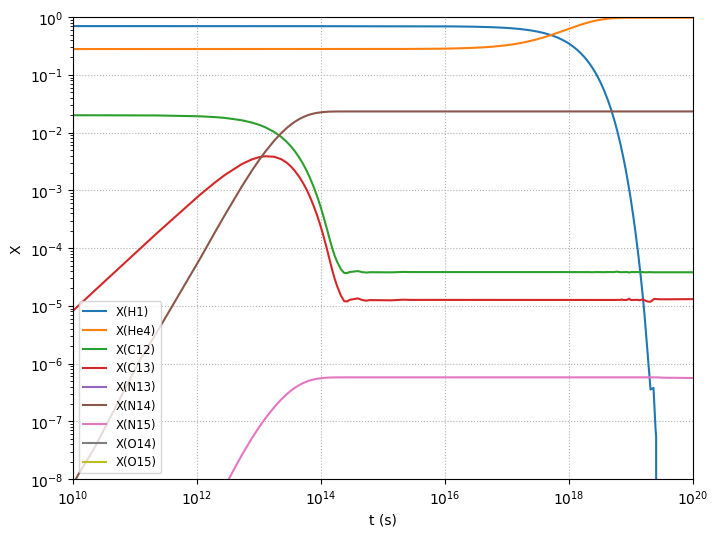

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

for i in range(cno.nnuc):
    ax.loglog(sol.t, sol.y[i,:] * cno.A[i], label=f"X({cno.names[i].capitalize()})")

ax.set_xlim(1.e10, 1.e20)
ax.set_ylim(1.e-8, 1.0)
ax.legend(fontsize="small")
ax.set_xlabel("t (s)")
ax.set_ylabel("X")
ax.grid(ls=":")

fig.set_size_inches((8, 6))

## Energy release

We can get the energy release from the change in molar abundances, $\Delta Y$.
This will be computed as:

$$\Delta E = -N_A \sum_i \Delta Y_i M_i$$

Here $M_i$ is the mass of the nucleus $i$ (this is tabulated in
the network as `mass[]`).

In [17]:
E = cno.energy_release(sol.y[:,-1] - Y0)
print(f"E = {E:20.10g}")

E =      4.510855593e+18


This result is in erg/g

We can compute the instantaneous energy generation rate as well,

$$\epsilon = -N_A \sum_i \frac{dY_i}{dt} M_i$$

In [18]:
epsilon = cno.energy_release(cno.rhs(0.0, Y0, rho, T))
print(f"epsilon = {epsilon:20.10g}")

epsilon =          117.7738358


```{tip}
{py:obj}`PythonNetwork <pynucastro.networks.python_network.PythonNetwork>` class provides the convenient method
{py:func}`integrate_network <pynucastro.networks.python_network.PythonNetwork.integrate_network>`,
which is a wrapper around `scipy.integrate.solve_ivp` for integrating the reaction network. This approach avoids the need to explicitly write out the Python module file via {py:func}`write_network <pynucastro.networks.rate_collection.RateCollection.write_network>`.
This method returns a {py:obj}`NetworkSolution <pynucastro.networks.python_network.NetworkSolution>` object that stores the solution of the system. It also contains convenient methods for post-processing and visualizations, such as {py:func}`plot_evolution <pynucastro.networks.python_network.NetworkSolution.plot_evolution>`,
which plots the time evolution of the mass fractions.
```

To demonstrate the use of {py:func}`integrate_network <pynucastro.networks.python_network.PythonNetwork.integrate_network>`, 
we will integrate the network with a different set of initial thermodynamic conditions. 
If no initial molar abundances are provided, the initial composition can be generated using one of three methods: `uniform`, `solar`, or `random`. In this example, we will use the `solar` composition. 
We can also specify a screening method to use, and we will use the `chugunov_2007` method for demonstration.

In [19]:
rho = 200
T = 3.e7
tmax = 1e20
sol = pynet.integrate_network(tmax, rho, T, screen_method="chugunov_2007", initial_comp="solar", rtol=1e-8, atol=1e-8)

The time evolution of the mass fractions can be visualized via built-in method {py:meth}`plot_evolution <pynucastro.networks.python_network.NetworkSolution.plot_evolution>`.

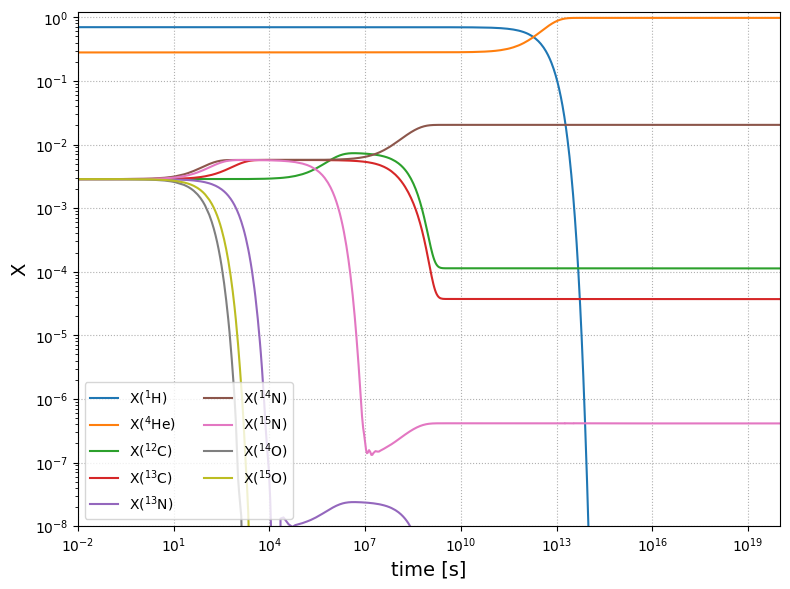

In [20]:
fig = sol.plot_evolution(tmin=1e-2, tmax=1e20, ymin=1e-8)

We can also evaluate the energy release in a similar fashion. 
Let's first consider computing the total energy release from the change in molar fractions using 
{py:func}`energy_release <pynucastro.networks.python_network.NetworkSolution.energy_release>`

In [21]:
E = sol.energy_release(sol.Y[:,-1] - sol.Y[:,0])
print(f"E = {E:20.10g}")

E =       4.51425955e+18


We can also compute the instantaneous energy release by using the rate of change of molar fractions from evaluating the {py:func}`rhs <pynucastro.networks.python_network.NetworkSolution.rhs>`

```{note}
`rhs` is automatically evaluated using the same thermodynamic condition and screening method used when integrating the network.
```

In [22]:
epsilon = sol.energy_release(sol.rhs(0.0, sol.Y[:,0]))
print(f"epsilon = {epsilon:20.10g}")

epsilon =      1.336802257e+13


Alternatively, we can use {py:func}`energy_release_at <pynucastro.networks.python_network.NetworkSolution.energy_release_at>`
to find the instantaneous energy release at any given time

In [23]:
initial_epsilon = sol.energy_release_at(sol.t[0])
print(f"initial_epsilon = {initial_epsilon:20.10g}")

final_epsilon = sol.energy_release_at(sol.t[-1])
print(f"final_epsilon   = {final_epsilon:20.10g}")

initial_epsilon =      1.336802257e+13
final_epsilon   =      -2.49335102e-22
